In [31]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import pink

from sparcl.client import SparclClient
from dl import queryClient as qc

import pandas as pd

In [2]:
print(qc.schema('desi_dr1.agnqso'))


Schema: desi_dr1
 Table: agnqso

     Column Name   Description
     -----------   -----------
               z   Redshift from the FastSpecFit catalog
            zerr   Redshift error
       target_ra   Right Ascension in decimal degrees (J2000)
      target_dec   Declination in decimal degrees (J2000)
         min_mjd   MJD of the first exposure in coadded spectrum
        mean_mjd   Mean of MJD of exposures in a coadded spectrum
         max_mjd   MJD of the last exposure in coadded spectrum
            elon   Ecliptic longitude
            elat   Ecliptic latitude
            glon   Galactic longitude
            glat   Galactic latitude
        targetid   Unique identifier for each object observed by DESI
           zwarn   Warning flags (0 is good)
           ls_id   Legacy Surveys DR9 identifier from RELEASE, OBJID, BRICKID
     desi_target   DESI (dark time program) target selection bitmask
     scnd_target   SCND (secondary program) target selection bitmask
      bgs_target 

In [33]:
query = """
        SELECT targetid, z, zerr, zwarn, civ_1549_flux, civ_1549_flux_ivar, civ_1549_sigma, flux_w3, flux_ivar_w3, spectype, survey
        FROM desi_dr1.agnqso
        WHERE (z BETWEEN 2 AND 3.4) AND (zwarn=0) AND (civ_1549_flux>0) AND (spectype!='STAR')
        """

In [ ]:
# results = qc.query(sql=query, fmt="pandas")

In [2]:
path = "data/query_results_from_dr1_agnqso.csv"
# results.to_csv(path)
results = pd.read_csv(path,index_col=0)
results

,targetid,z,zerr,zwarn,civ_1549_flux,civ_1549_flux_ivar,civ_1549_sigma,flux_w3,flux_ivar_w3,spectype,survey
0,39633221419275546,2.440016,0.000635,0,208.402770,0.020173,3418.65480,19.313930,0.002920,QSO,main
1,39633217375964718,2.117797,0.000656,0,110.908840,0.012570,3048.58330,8.500388,0.003168,QSO,main
2,39633217375961604,2.189153,0.000326,0,43.242090,0.070611,597.65550,13.696554,0.002910,QSO,main
3,39633221419271454,2.320267,0.000859,0,233.598630,0.013143,4489.66750,2.761181,0.003186,QSO,main
4,39633221419271778,2.218200,0.000769,0,100.735690,0.016395,3171.20200,-81.434450,0.003246,QSO,main
...,...,...,...,...,...,...,...,...,...,...,...
532230,39633158747983618,2.327047,0.000193,0,210.939650,0.032602,1647.80700,-55.228440,0.002901,QSO,main
532231,39633158747985967,2.392584,0.000163,0,888.902300,0.013076,2714.59160,57.523330,0.003068,QSO,main
532232,39633158747983695,2.770790,0.000210,0,59.914715,0.108804,818.77783,-5.375127,0.002865,QSO,main
532233,39633158752174909,2.109610,0.000269,0,352.783540,0.016585,1963.30530,18.227741,0.002832,QSO,main


In [43]:
results.query("flux_w3 > 0").describe()

,targetid,z,zerr,zwarn,civ_1549_flux,civ_1549_flux_ivar,civ_1549_sigma,flux_w3,flux_ivar_w3
count,3.872090e+05,387209.000000,387209.000000,387209.0,3.872090e+05,387209.000000,387209.000000,3.872090e+05,3.872090e+05
mean,4.214778e+16,2.457588,0.000526,0.0,2.464328e+02,0.088083,2373.320126,1.729816e+02,1.465717e-03
std,7.926295e+16,0.345271,0.000458,0.0,3.735836e+02,0.151691,1103.441561,4.174118e+04,4.321727e-03
min,1.036098e+14,2.000003,0.000007,0.0,3.712253e-15,0.000138,1.319500,4.383427e-04,2.676366e-10
25%,3.962778e+16,2.172885,0.000220,0.0,6.077483e+01,0.026542,1663.184000,2.658328e+01,7.787828e-04
50%,3.962803e+16,2.381043,0.000396,0.0,1.355672e+02,0.049716,2338.461700,5.541196e+01,1.037603e-03
75%,3.962849e+16,2.678330,0.000693,0.0,2.888094e+02,0.098643,2970.663600,1.025097e+02,1.502425e-03
max,2.305843e+18,3.399991,0.023978,0.0,1.533291e+04,10.003573,9999.760000,2.564666e+07,2.832991e-01


In [5]:
idxs = results["targetid"].to_list()

client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [35]:
idxs = [int(x) for x in idxs]

output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

spectra = client.retrieve_by_specid(specid_list=idxs[:100], include=output_fields,dataset_list=["DESI-DR1"])

In [37]:
spectra_df = pd.DataFrame(spectra.data[1:])
spectra_df

,specprimary,targetid,redshift,spectype,redshift_warning,data_release,specid,desi_target,survey,flux,wavelength,_dr
0,True,39633217375964718,2.117797,QSO,0,DESI-DR1,39633217375964718,3622,main,"[3.0574047565460205, -4.14963960647583, 3.7412...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,True,39633221415078425,1.675163,GALAXY,0,DESI-DR1,39633221415078425,4611686018427388932,main,"[7.159254550933838, 2.400733709335327, 3.90905...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,True,39633229434590521,2.470137,QSO,0,DESI-DR1,39633229434590521,3622,main,"[1.948269248008728, -2.286224842071533, -5.793...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,True,39633221419271454,2.320267,QSO,0,DESI-DR1,39633221419271454,4611686018427391526,main,"[-0.18166252970695496, 2.3862175941467285, 0.5...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,True,39633221419271469,2.067840,QSO,0,DESI-DR1,39633221419271469,4611686018427388932,main,"[0.33395111560821533, 2.2995874881744385, 1.32...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,True,39633253044328051,3.170602,QSO,0,DESI-DR1,39633253044328051,4611686018427388932,main,"[-3.4286065101623535, -4.025493144989014, 2.56...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
96,True,39633249160397455,2.083748,QSO,0,DESI-DR1,39633249160397455,1028,main,"[4.019814968109131, -0.33092859387397766, 1.18...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
97,True,39633245259697675,2.454184,QSO,0,DESI-DR1,39633245259697675,1028,main,"[0.507190465927124, 1.4882186651229858, 2.1702...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
98,True,39633233414985075,2.122703,QSO,0,DESI-DR1,39633233414985075,3622,main,"[-1.4262645244598389, -0.6911202073097229, 3.4...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


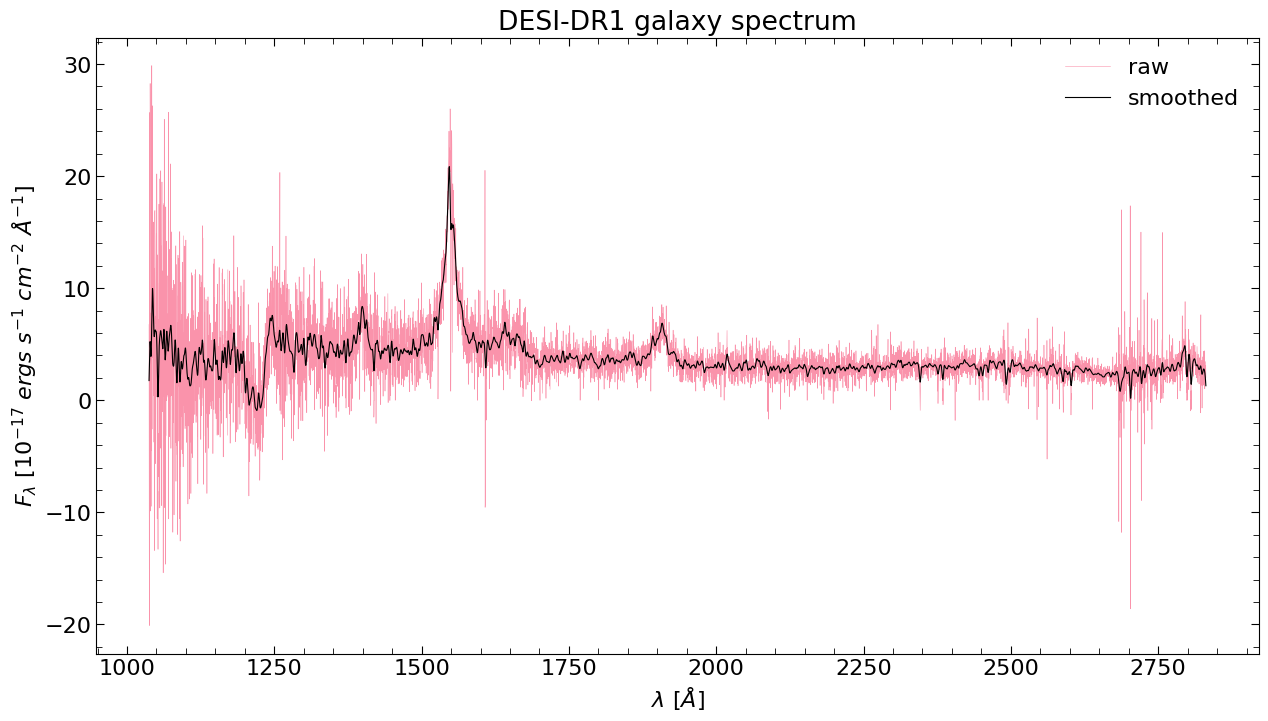

In [ ]:
idx = 2

lam = spectra_df["wavelength"][idx]
flux = spectra_df["flux"][idx]
z = spectra_df["redshift"][idx]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux)



